# Brand Price Gap Dynamics Over Time

Tracks the daily branded vs. generic price gap per category across the 88-day observation window (Dec 18, 2025 – Mar 2026).

**Brand quadrant classification:**
- Household Giant (High Recognition | Generic Price)
- Prestige Leader (High Recognition | Premium Price)
- Niche Professional (Low Recognition | Premium Price)
- Local & Value (Low Recognition | Generic Price)

**Research questions:**
1. Is the branded-generic price gap stable over time, or does it widen/compress?
2. Does the gap behave differently across categories?
3. Is there a visible Tet effect (around Feb 17, 2026)?
4. Do different brand quadrants show different gap dynamics?

**Outputs:**
- `output/brand_gap_daily.csv` — daily × category timeseries (branded vs. generic)
- `output/brand_gap_daily_by_quadrant.csv` — daily × category × quadrant timeseries
- `output/brand_gap_summary.csv` — per-category summary with Tet comparison
- 4+ figures

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from scipy import stats

from src.build_product_dataset import load_category, CATEGORIES, _extract_brand_name
from src.brand_quadrants import BRAND_QUADRANTS, QUADRANT_LABELS
from src.utils import PROJECT_ROOT

TET_DATE = pd.Timestamp('2026-02-17')
TET_WINDOW_START = pd.Timestamp('2026-02-10')
TET_WINDOW_END   = pd.Timestamp('2026-02-24')

print('Libraries loaded.')

Libraries loaded.


## 1. Build daily panel with brand labels

In [2]:
frames = []
for cat in CATEGORIES:
    daily = load_category(cat)
    if daily.empty:
        continue
    # Extract brand name and quadrant
    daily['brand_name'] = daily['product_name'].map(_extract_brand_name)
    daily['is_branded'] = (daily['brand_name'] != '').astype(int)
    daily['brand_quadrant'] = daily['brand_name'].map(BRAND_QUADRANTS).fillna('')
    # For unbranded products, label as 'generic'
    daily.loc[daily['brand_quadrant'] == '', 'brand_quadrant'] = 'generic'
    frames.append(daily)

panel = pd.concat(frames, ignore_index=True)
panel['date'] = pd.to_datetime(panel['date'])

# Marked price: fill 0/NaN with final_price (non-promo days)
panel['marked_price_eff'] = panel['marked_price'].where(
    panel['marked_price'] > 0, panel['final_price']
)

print(f"Panel: {len(panel):,} rows, {panel['date'].nunique()} dates, "
      f"{panel['parent_category'].nunique()} categories")
print(f"Branded rows: {panel['is_branded'].sum():,} ({panel['is_branded'].mean()*100:.1f}%)")
print()
print("Brand quadrant distribution:")
print(panel['brand_quadrant'].value_counts())

Panel: 105,088 rows, 98 dates, 10 categories
Branded rows: 77,749 (74.0%)

Brand quadrant distribution:
brand_quadrant
local_value           28474
household_giant       28474
generic               27339
niche_professional    14664
prestige_leader        6137
Name: count, dtype: int64


## 2. Compute daily branded vs. generic gap per category

In [3]:
def compute_daily_gap(panel: pd.DataFrame, price_col: str) -> pd.DataFrame:
    """For each date × category, compute median price by brand tier and the gap."""
    grp = (
        panel
        .groupby(['date', 'parent_category', 'is_branded'])[price_col]
        .median()
        .unstack('is_branded')
    )
    grp.columns = ['generic', 'branded']
    grp = grp.dropna(subset=['generic', 'branded'])  # need both tiers present
    grp['gap_abs'] = grp['branded'] - grp['generic']
    grp['gap_pct'] = (grp['branded'] - grp['generic']) / grp['generic'] * 100
    return grp.reset_index()

gap_final  = compute_daily_gap(panel, 'final_price')
gap_marked = compute_daily_gap(panel, 'marked_price_eff')

# Merge into single DataFrame
gap = gap_final.merge(
    gap_marked[['date', 'parent_category', 'branded', 'generic', 'gap_abs', 'gap_pct']],
    on=['date', 'parent_category'],
    suffixes=('_final', '_marked'),
)

# Identify categories with enough branded data (≥10 days with both tiers)
coverage = gap.groupby('parent_category')['date'].count()
valid_cats = coverage[coverage >= 10].index.tolist()
print(f"Categories with ≥10 days of branded+generic coverage: {valid_cats}")
gap = gap[gap['parent_category'].isin(valid_cats)].copy()

# Save raw timeseries
out_path = PROJECT_ROOT / 'output' / 'brand_gap_daily.csv'
gap.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved {len(gap)} rows → {out_path}")
gap.head()

Categories with ≥10 days of branded+generic coverage: ['Bánh Kẹo', 'Chăm Sóc Bé', 'Gia Vị', 'Mì - Thực Phẩm Ăn Liền', 'Rau - Củ - Trái Cây', 'Sữa Tươi', 'Thực Phẩm Chế Biến', 'Thực Phẩm Khô', 'Thực Phẩm Đông Lạnh', 'Trứng - Đậu Hũ']
Saved 854 rows → /Users/my/Online Food Price/notebooks/../output/brand_gap_daily.csv


,date,parent_category,generic_final,branded_final,gap_abs_final,gap_pct_final,branded_marked,generic_marked,gap_abs_marked,gap_pct_marked
0,2025-12-18,Chăm Sóc Bé,60900.0,88350.0,27450.0,45.073892,89750.0,129000.0,-39250.0,-30.426357
1,2025-12-18,Gia Vị,92400.0,39700.0,-52700.0,-57.034632,40200.0,92400.0,-52200.0,-56.493506
2,2025-12-18,Mì - Thực Phẩm Ăn Liền,27200.0,19500.0,-7700.0,-28.308824,25600.0,33900.0,-8300.0,-24.483776
3,2025-12-18,Rau - Củ - Trái Cây,36320.0,47400.0,11080.0,30.506608,47400.0,39900.0,7500.0,18.796992
4,2025-12-18,Sữa Tươi,39000.0,35200.0,-3800.0,-9.743590,36900.0,39000.0,-2100.0,-5.384615


## 3. Summary statistics per category

In [4]:
summary_rows = []
for cat, df_cat in gap.groupby('parent_category'):
    df_cat = df_cat.sort_values('date')
    
    in_tet  = df_cat['date'].between(TET_WINDOW_START, TET_WINDOW_END)
    out_tet = ~in_tet

    # OLS trend: gap_pct_final vs. days since first date
    days = (df_cat['date'] - df_cat['date'].min()).dt.days.values
    if len(days) >= 5:
        slope, intercept, r, p_trend, _ = stats.linregress(days, df_cat['gap_pct_final'].values)
    else:
        slope, p_trend = np.nan, np.nan

    row = {
        'category': cat,
        'n_days': len(df_cat),
        'mean_gap_pct_final': df_cat['gap_pct_final'].mean(),
        'std_gap_pct_final': df_cat['gap_pct_final'].std(),
        'mean_gap_pct_marked': df_cat['gap_pct_marked'].mean(),
        'mean_gap_abs_final': df_cat['gap_abs_final'].mean(),
        'tet_mean_gap_pct': df_cat.loc[in_tet, 'gap_pct_final'].mean() if in_tet.any() else np.nan,
        'non_tet_mean_gap_pct': df_cat.loc[out_tet, 'gap_pct_final'].mean() if out_tet.any() else np.nan,
        'gap_trend_slope_per_day': slope,
        'gap_trend_p': p_trend,
    }
    row['tet_delta_pct'] = row['tet_mean_gap_pct'] - row['non_tet_mean_gap_pct']
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).round(3)
summary = summary.sort_values('mean_gap_pct_final', ascending=False)

out_path = PROJECT_ROOT / 'output' / 'brand_gap_summary.csv'
summary.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved {len(summary)} rows → {out_path}")
summary

Saved 10 rows → /Users/my/Online Food Price/notebooks/../output/brand_gap_summary.csv


,category,n_days,mean_gap_pct_final,std_gap_pct_final,mean_gap_pct_marked,mean_gap_abs_final,tet_mean_gap_pct,non_tet_mean_gap_pct,gap_trend_slope_per_day,gap_trend_p,tet_delta_pct
9,Trứng - Đậu Hũ,92,176.715,60.048,176.715,30639.130,201.321,172.666,-0.047,0.825,28.655
4,Rau - Củ - Trái Cây,94,42.903,76.661,40.110,11332.713,79.120,37.090,0.616,0.021,42.030
0,Bánh Kẹo,53,31.155,39.738,33.607,11599.528,35.277,29.815,-0.462,0.163,5.462
6,Thực Phẩm Chế Biến,87,19.606,56.870,15.956,-1333.908,-14.362,25.041,0.414,0.048,-39.404
3,Mì - Thực Phẩm Ăn Liền,77,18.664,62.288,19.345,568.182,26.126,18.146,1.308,0.000,7.980
1,Chăm Sóc Bé,96,7.275,44.404,-36.294,-32446.354,9.579,6.914,-0.762,0.000,2.665
8,Thực Phẩm Đông Lạnh,96,-7.586,15.272,-7.642,-8243.750,-6.059,-7.825,-0.200,0.000,1.766
5,Sữa Tươi,90,-9.001,45.393,-8.910,-8794.444,-6.256,-9.383,-0.220,0.177,3.127
7,Thực Phẩm Khô,96,-10.067,17.883,-9.066,-7516.667,-20.394,-8.449,-0.135,0.029,-11.945
2,Gia Vị,73,-48.896,12.086,-47.140,-46437.671,-60.643,-47.244,0.143,0.001,-13.399


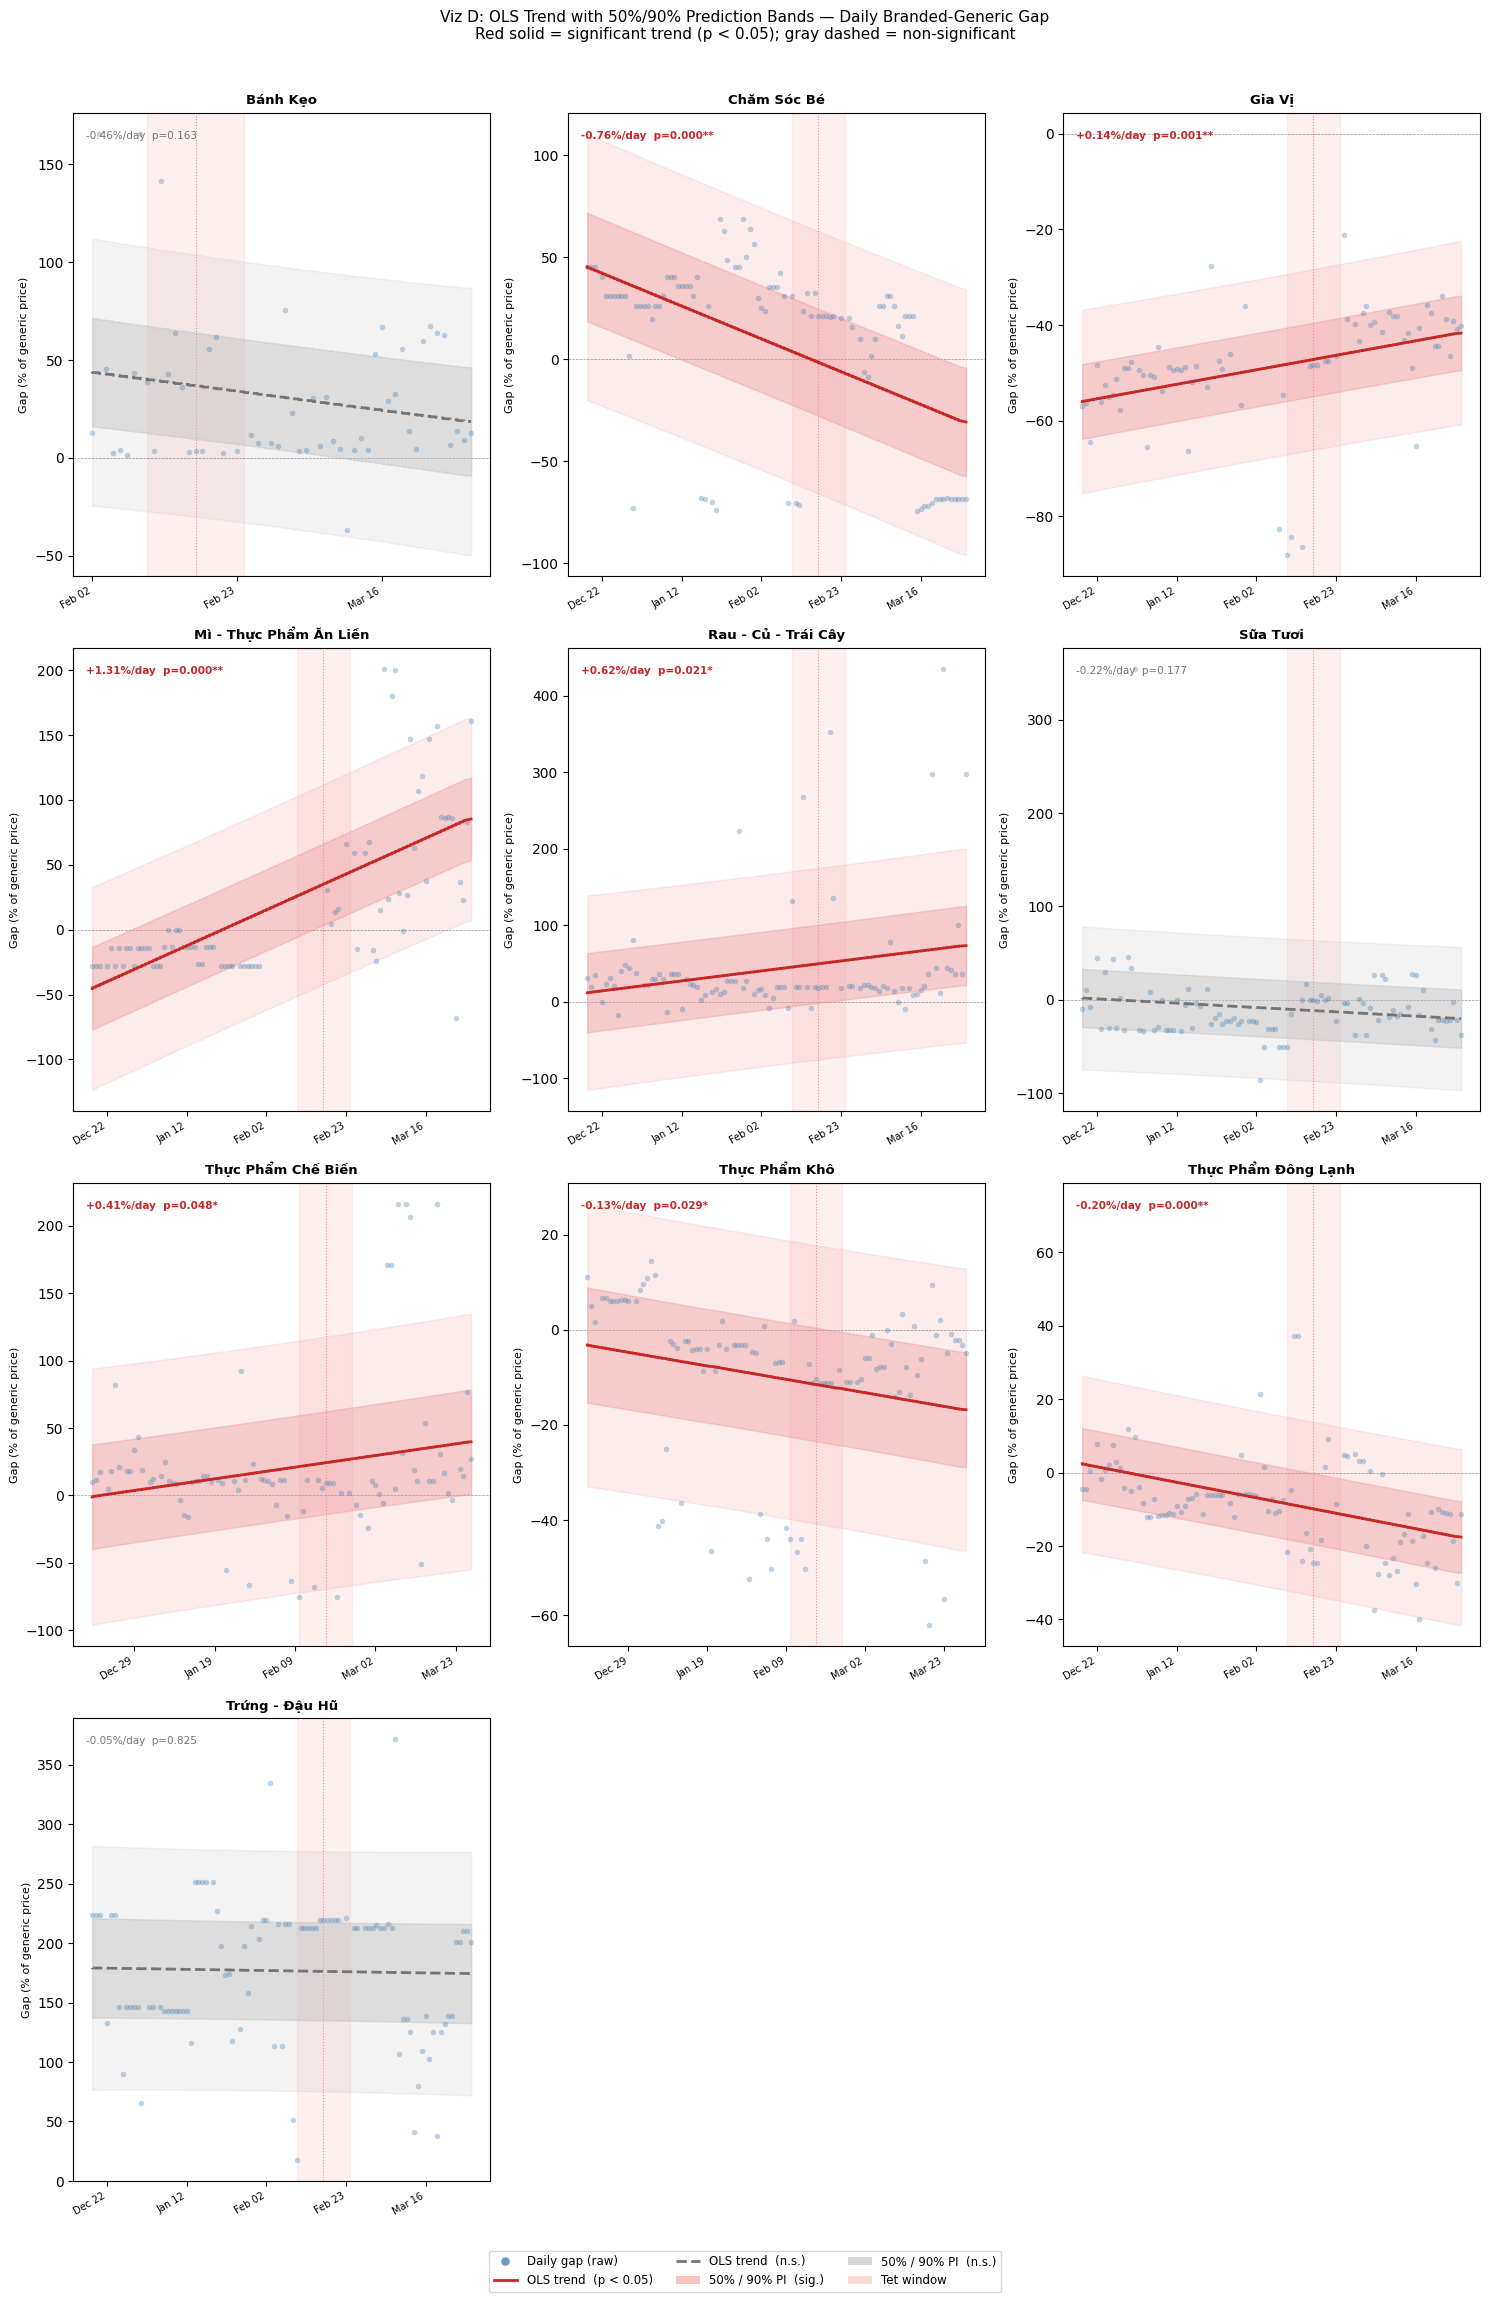

Viz D saved.


In [5]:
## --- Visualization D: OLS Trend Lines with 50%/90% Prediction Bands ---
import statsmodels.api as sm_nb10
import matplotlib.patches as _Patch_nb10

_cats_d = sorted(gap['parent_category'].unique())
_n_cats_d  = len(_cats_d)
_ncols_d   = 3
_nrows_d   = int(np.ceil(_n_cats_d / _ncols_d))

fig, axes = plt.subplots(_nrows_d, _ncols_d, figsize=(15, 5.5 * _nrows_d), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(_cats_d):
    ax = axes[i]
    _df_d = gap[gap['parent_category'] == cat].sort_values('date').copy()
    _df_d['_days'] = (_df_d['date'] - _df_d['date'].min()).dt.days

    _Xd   = sm_nb10.add_constant(_df_d['_days'].values.astype(float))
    _yd   = _df_d['gap_pct_final'].values
    _ols_d = sm_nb10.OLS(_yd, _Xd).fit()

    _slope_d = _ols_d.params[1]
    _pval_d  = _ols_d.pvalues[1]
    _is_sig_d = _pval_d < 0.05

    _xg_d  = np.linspace(_df_d['_days'].min(), _df_d['_days'].max(), 200)
    _Xg_d  = sm_nb10.add_constant(_xg_d)
    _p90_d = _ols_d.get_prediction(_Xg_d).summary_frame(alpha=0.1)
    _p50_d = _ols_d.get_prediction(_Xg_d).summary_frame(alpha=0.5)

    _first_date_d = _df_d['date'].min()
    _xdates_d = [_first_date_d + pd.Timedelta(days=int(dd)) for dd in _xg_d]

    _lc_d = '#C62828' if _is_sig_d else '#757575'
    _bc_d = '#EF9A9A' if _is_sig_d else '#BDBDBD'

    # Tet shading (behind everything)
    ax.axvspan(TET_WINDOW_START, TET_WINDOW_END, color='red', alpha=0.06, zorder=0)
    ax.axvline(TET_DATE, color='red', linewidth=0.8, linestyle=':', alpha=0.45, zorder=1)

    # 90% PI band
    ax.fill_between(_xdates_d, _p90_d['obs_ci_lower'], _p90_d['obs_ci_upper'],
                    alpha=0.18, color=_bc_d, zorder=2)
    # 50% PI band
    ax.fill_between(_xdates_d, _p50_d['obs_ci_lower'], _p50_d['obs_ci_upper'],
                    alpha=0.40, color=_bc_d, zorder=3)

    # Raw scatter
    ax.scatter(_df_d['date'], _df_d['gap_pct_final'],
               color='steelblue', alpha=0.35, s=16, zorder=4, linewidths=0)

    # OLS trend line
    ax.plot(_xdates_d, _p90_d['mean'],
            color=_lc_d, linewidth=2.0, zorder=5,
            linestyle='-' if _is_sig_d else '--')

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)

    _sign_d  = '+' if _slope_d >= 0 else ''
    _stars_d = '**' if _pval_d < 0.01 else ('*' if _pval_d < 0.05 else '')
    ax.text(0.03, 0.96,
            f'{_sign_d}{_slope_d:.2f}%/day  p={_pval_d:.3f}{_stars_d}',
            transform=ax.transAxes, fontsize=7.5, va='top',
            color=_lc_d, fontweight='bold' if _is_sig_d else 'normal')

    ax.set_title(cat, fontsize=9.5, fontweight='bold')
    ax.set_ylabel('Gap (% of generic price)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

_handles_d = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, alpha=0.8, label='Daily gap (raw)'),
    plt.Line2D([0],[0], color='#C62828', linewidth=2,              label='OLS trend  (p < 0.05)'),
    plt.Line2D([0],[0], color='#757575', linewidth=2, linestyle='--', label='OLS trend  (n.s.)'),
    _Patch_nb10.Patch(facecolor='#EF9A9A', alpha=0.6, label='50% / 90% PI  (sig.)'),
    _Patch_nb10.Patch(facecolor='#BDBDBD', alpha=0.6, label='50% / 90% PI  (n.s.)'),
    _Patch_nb10.Patch(facecolor='red',     alpha=0.15, label='Tet window'),
]
fig.legend(handles=_handles_d, loc='lower center', ncol=3, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    'Viz D: OLS Trend with 50%/90% Prediction Bands — Daily Branded-Generic Gap\n'
    'Red solid = significant trend (p < 0.05); gray dashed = non-significant',
    fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'output' / 'thesis_vizD_ols_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Viz D saved.')


## Figure 1: Branded-Generic Price Gap Over Time (Final Price, per category)

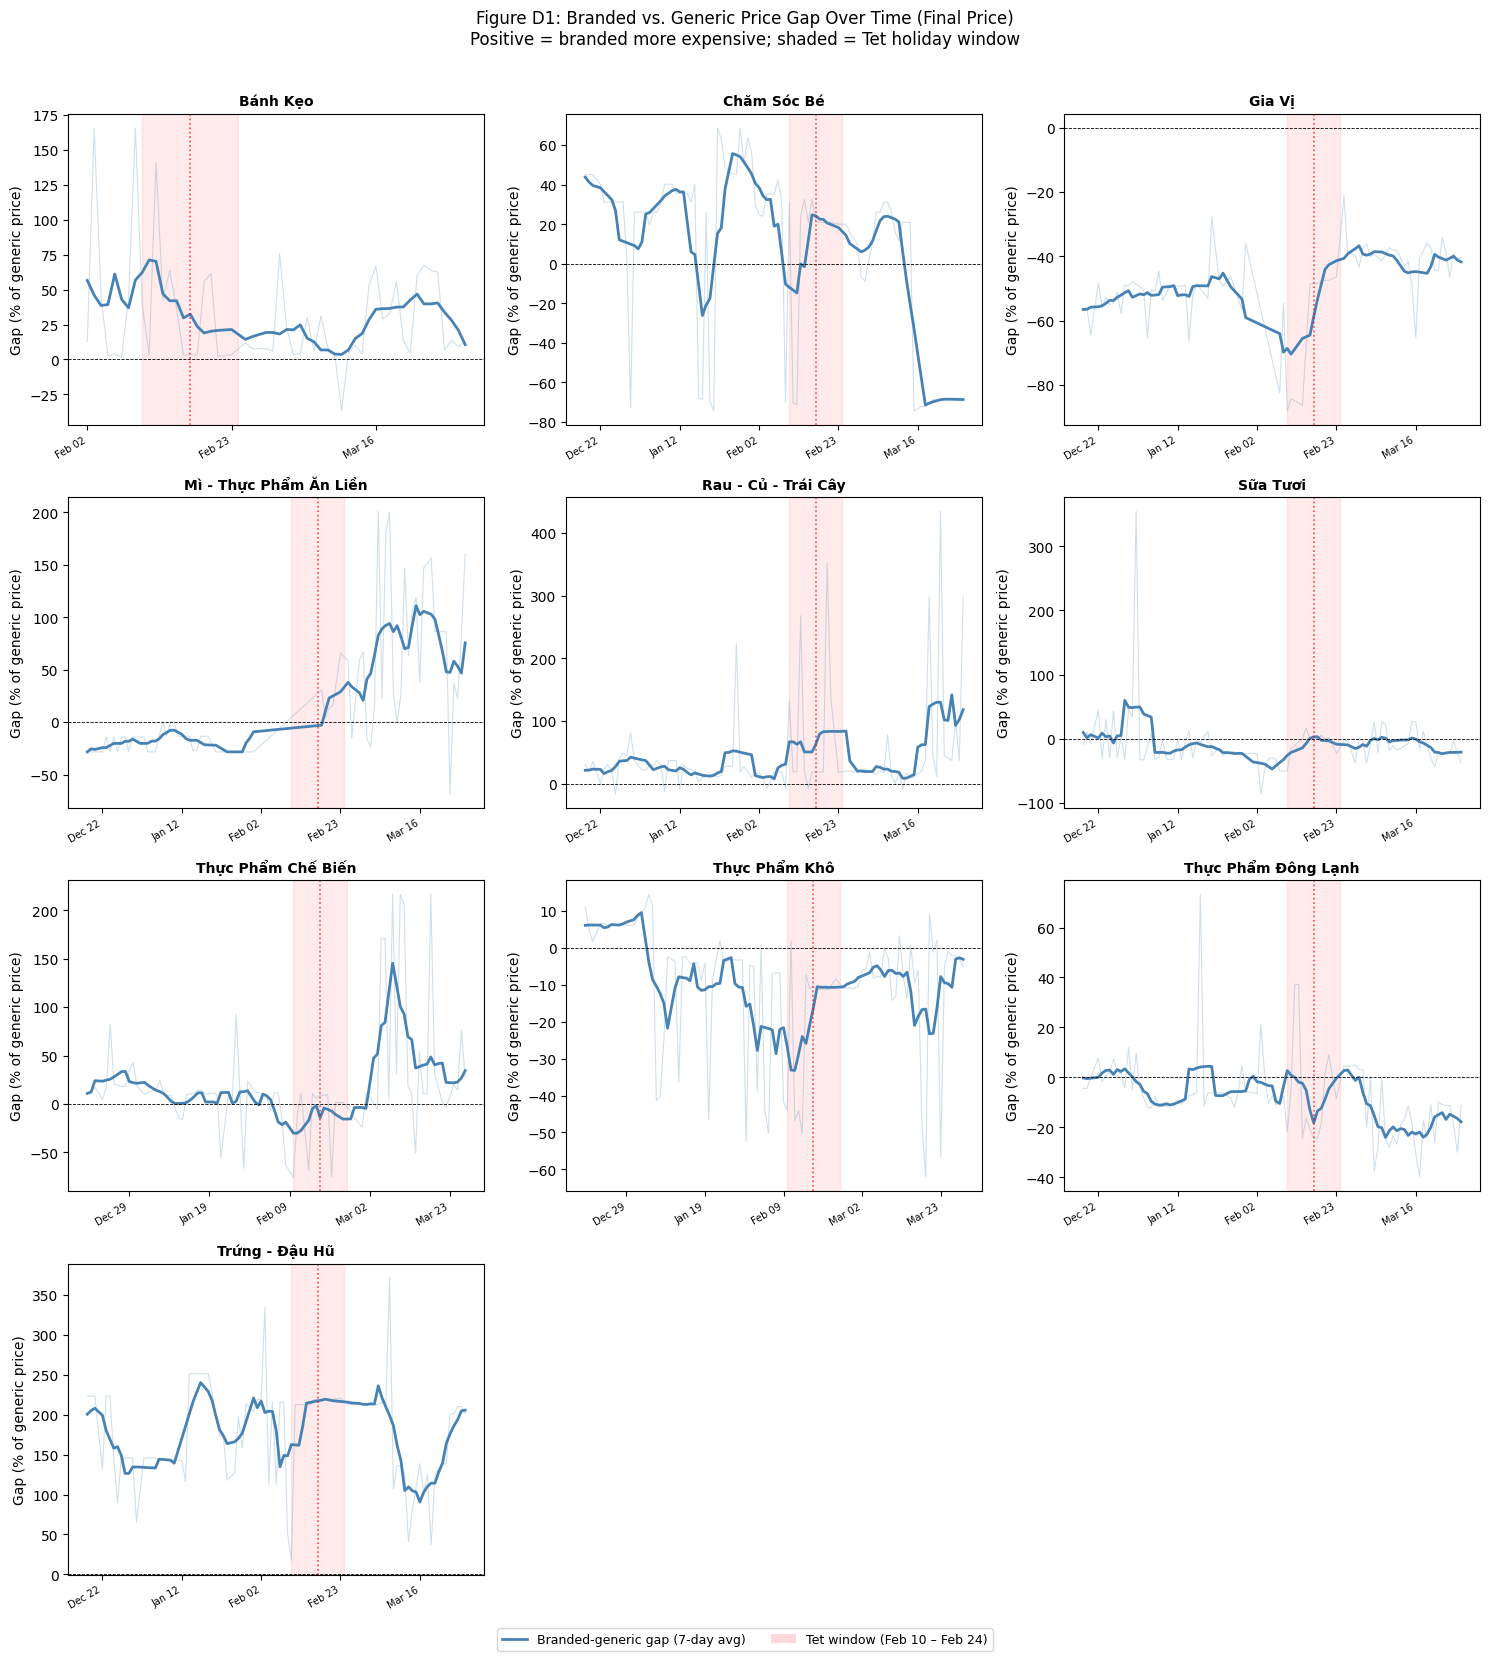

Figure D1 saved.


In [6]:
cats = gap['parent_category'].unique()
n_cats = len(cats)
ncols = 3
nrows = int(np.ceil(n_cats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(sorted(cats)):
    ax = axes[i]
    df_cat = gap[gap['parent_category'] == cat].sort_values('date')

    # Raw and smoothed (7-day rolling)
    raw = df_cat.set_index('date')['gap_pct_final']
    smoothed = raw.rolling(7, min_periods=3, center=True).mean()

    ax.plot(raw.index, raw.values, color='steelblue', alpha=0.25, linewidth=0.8)
    ax.plot(smoothed.index, smoothed.values, color='steelblue', linewidth=2, label='7-day avg')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')

    # Tet shading
    ax.axvspan(TET_WINDOW_START, TET_WINDOW_END, color='red', alpha=0.08, label='Tet window')
    ax.axvline(TET_DATE, color='red', linewidth=1.2, linestyle=':', alpha=0.7)

    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Gap (% of generic price)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [
    plt.Line2D([0], [0], color='steelblue', linewidth=2, label='Branded-generic gap (7-day avg)'),
    Patch(facecolor='red', alpha=0.15, label='Tet window (Feb 10 – Feb 24)'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Figure D1: Branded vs. Generic Price Gap Over Time (Final Price)\n'
    'Positive = branded more expensive; shaded = Tet holiday window',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'output' / 'thesis_figD1_gap_over_time.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Figure D1 saved.')

## Figure 2: Final Price Gap vs. Marked Price Gap (Do Promotions Narrow the Gap?)

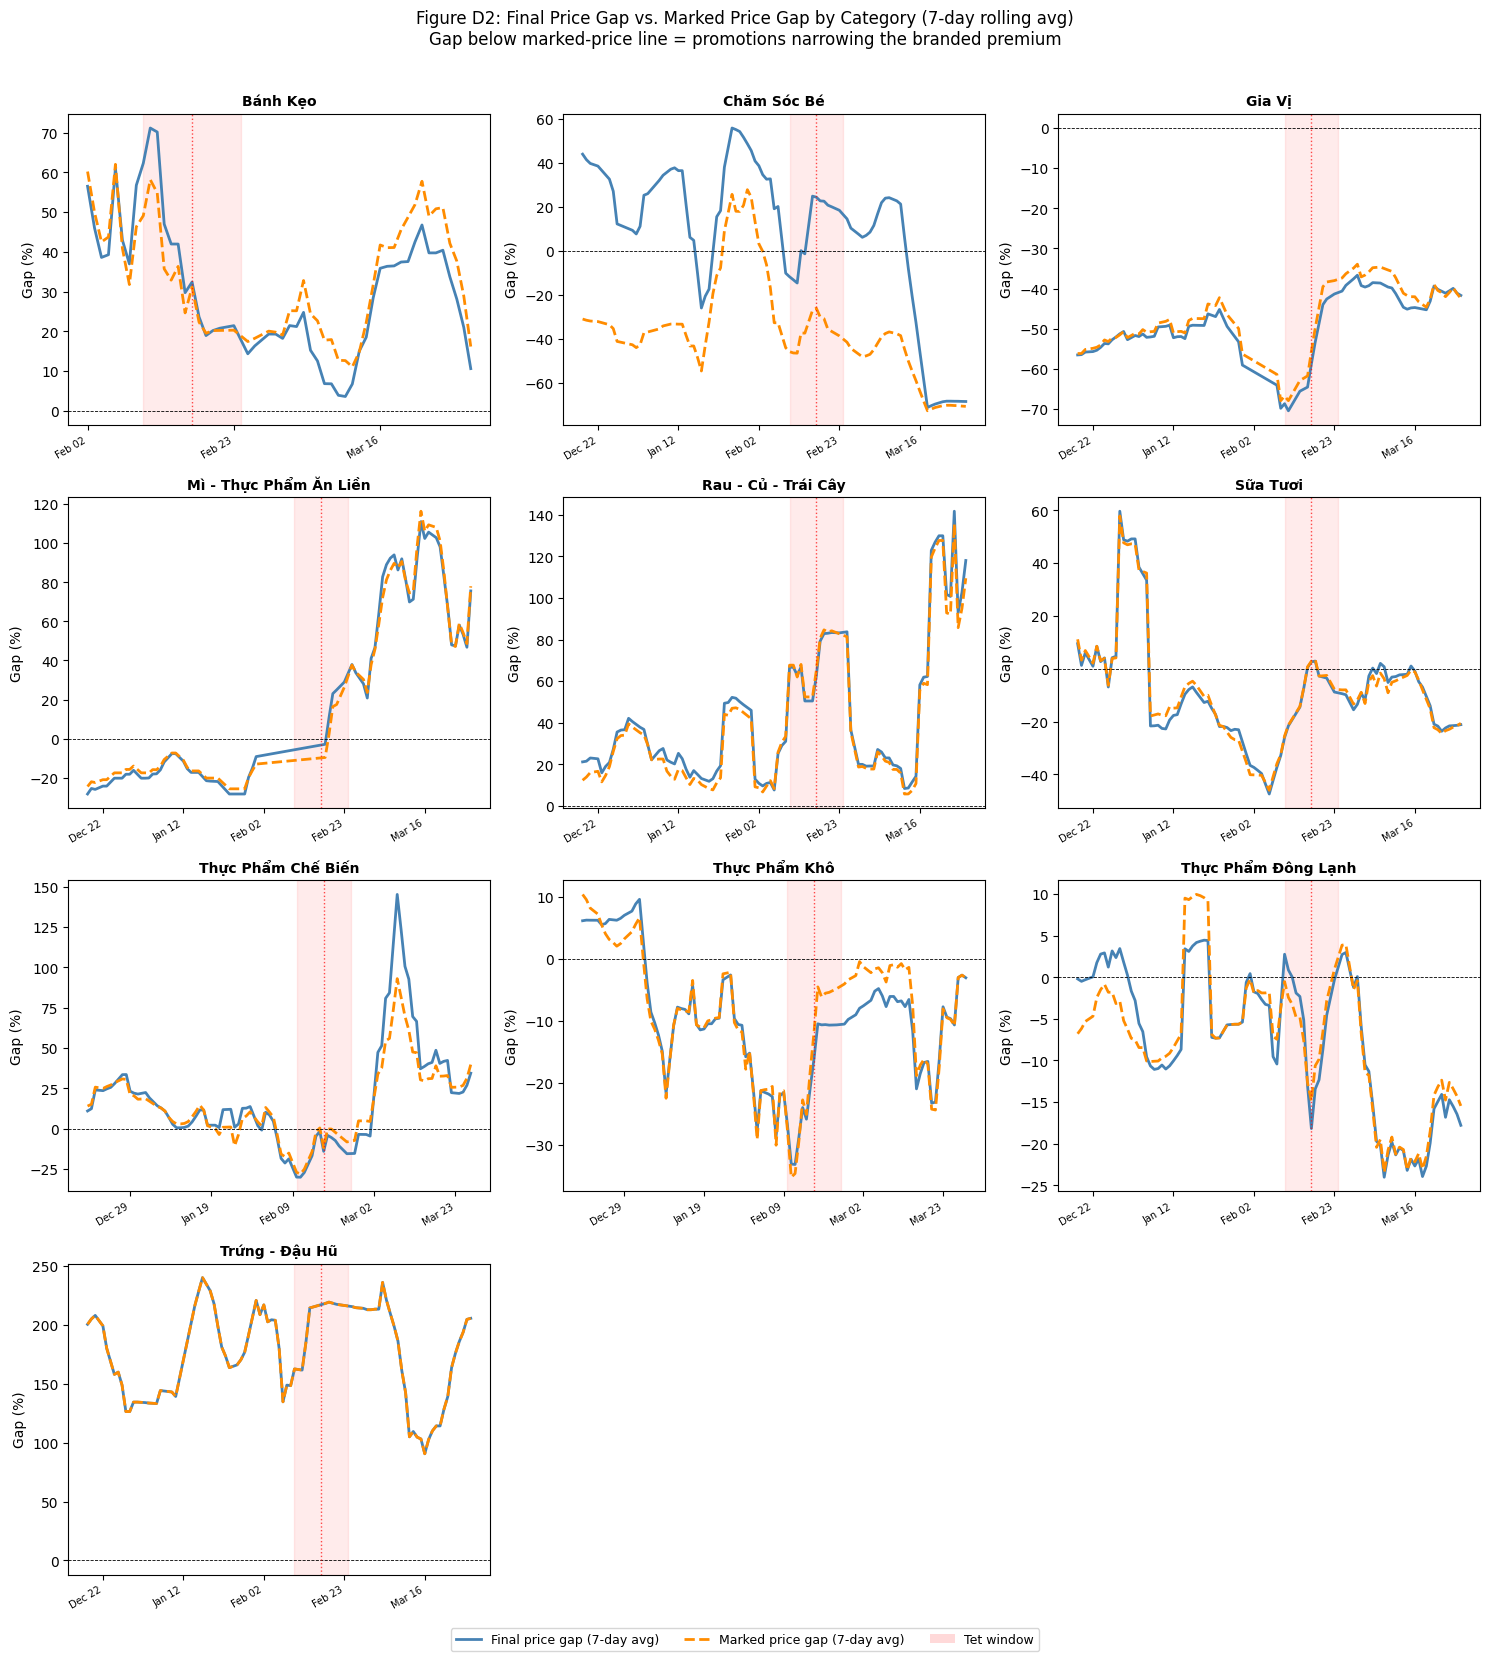

Figure D2 saved.


In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(sorted(cats)):
    ax = axes[i]
    df_cat = gap[gap['parent_category'] == cat].sort_values('date').set_index('date')

    smooth_final  = df_cat['gap_pct_final'].rolling(7, min_periods=3, center=True).mean()
    smooth_marked = df_cat['gap_pct_marked'].rolling(7, min_periods=3, center=True).mean()

    ax.plot(smooth_final.index,  smooth_final.values,  color='steelblue', linewidth=2, label='Final price gap')
    ax.plot(smooth_marked.index, smooth_marked.values, color='darkorange', linewidth=2,
            linestyle='--', label='Marked price gap')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.axvspan(TET_WINDOW_START, TET_WINDOW_END, color='red', alpha=0.08)
    ax.axvline(TET_DATE, color='red', linewidth=1.0, linestyle=':', alpha=0.7)

    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Gap (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles = [
    plt.Line2D([0], [0], color='steelblue', linewidth=2, label='Final price gap (7-day avg)'),
    plt.Line2D([0], [0], color='darkorange', linewidth=2, linestyle='--', label='Marked price gap (7-day avg)'),
    Patch(facecolor='red', alpha=0.15, label='Tet window'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Figure D2: Final Price Gap vs. Marked Price Gap by Category (7-day rolling avg)\n'
    'Gap below marked-price line = promotions narrowing the branded premium',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'output' / 'thesis_figD2_final_vs_marked_gap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Figure D2 saved.')

## Figure 3: Tet Window Detail (±14 days)

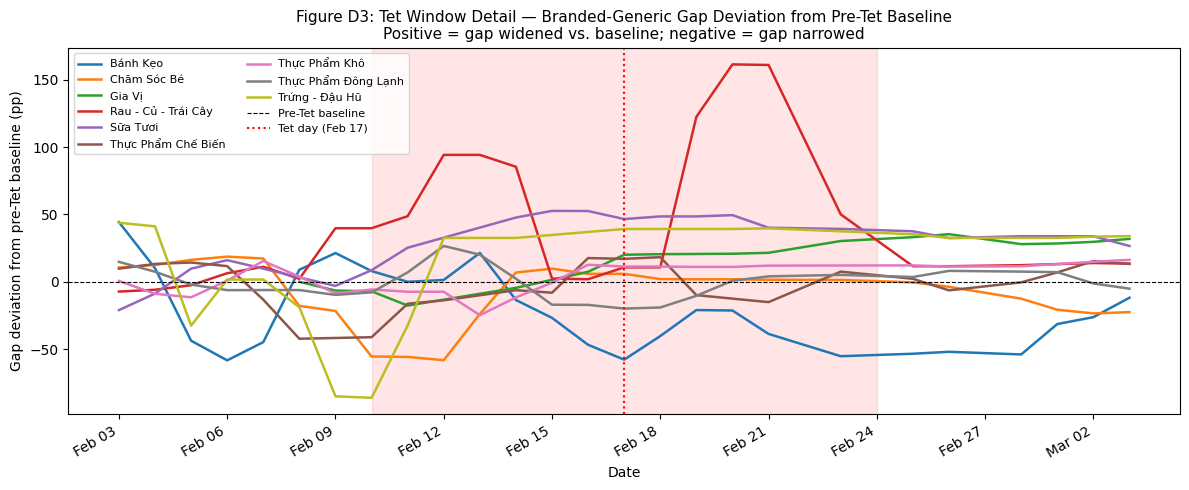

Figure D3 saved.


In [8]:
tet_start_zoom = pd.Timestamp('2026-02-03')
tet_end_zoom   = pd.Timestamp('2026-03-03')

gap_tet = gap[gap['date'].between(tet_start_zoom, tet_end_zoom)].copy()

# Normalize gap to pre-Tet baseline (Feb 3–9 mean, the week before Tet window)
pre_tet = gap[gap['date'].between(pd.Timestamp('2026-02-03'), pd.Timestamp('2026-02-09'))]
baseline = pre_tet.groupby('parent_category')['gap_pct_final'].mean().rename('baseline')
gap_tet = gap_tet.merge(baseline, on='parent_category')
gap_tet['gap_indexed'] = gap_tet['gap_pct_final'] - gap_tet['baseline']  # deviation from pre-Tet

fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.tab10.colors
for j, cat in enumerate(sorted(gap_tet['parent_category'].unique())):
    df_cat = gap_tet[gap_tet['parent_category'] == cat].sort_values('date').set_index('date')
    smoothed = df_cat['gap_indexed'].rolling(3, min_periods=1, center=True).mean()
    ax.plot(smoothed.index, smoothed.values, linewidth=1.8, label=cat, color=colors[j % 10])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Pre-Tet baseline')
ax.axvspan(TET_WINDOW_START, TET_WINDOW_END, color='red', alpha=0.10)
ax.axvline(TET_DATE, color='red', linewidth=1.5, linestyle=':', label='Tet day (Feb 17)')

ax.set_xlabel('Date')
ax.set_ylabel('Gap deviation from pre-Tet baseline (pp)')
ax.set_title(
    'Figure D3: Tet Window Detail — Branded-Generic Gap Deviation from Pre-Tet Baseline\n'
    'Positive = gap widened vs. baseline; negative = gap narrowed',
    fontsize=11
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'output' / 'thesis_figD3_tet_window.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Figure D3 saved.')

## Figure 4: Mean Gap by Category — Pre-Tet / Tet / Post-Tet

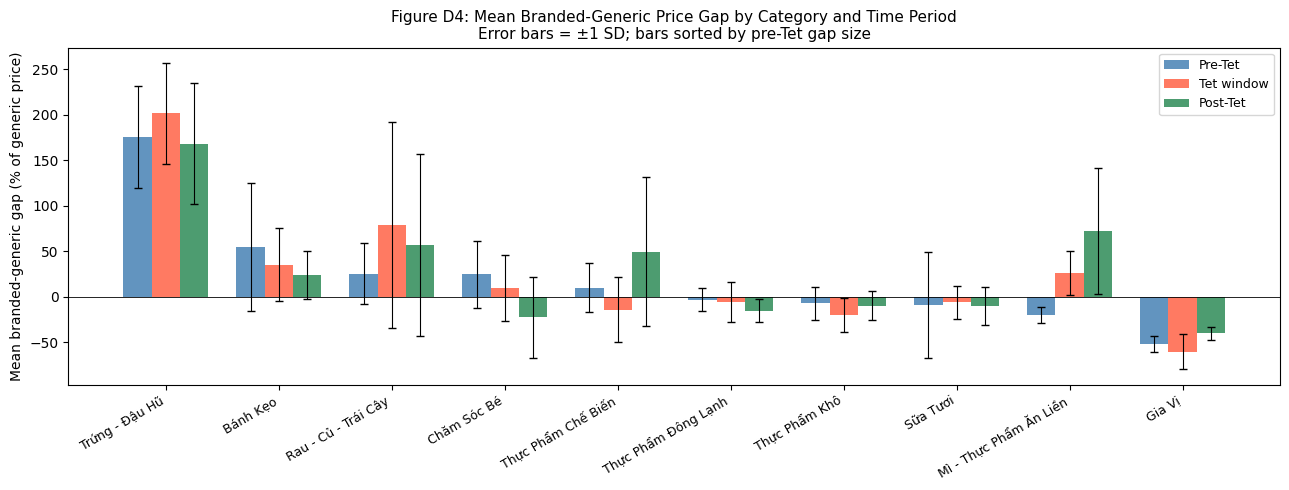

Figure D4 saved.


In [9]:
# Define three periods
def period_label(date):
    if date < TET_WINDOW_START:
        return 'Pre-Tet'
    elif date <= TET_WINDOW_END:
        return 'Tet window'
    else:
        return 'Post-Tet'

gap['period'] = gap['date'].map(period_label)

period_means = (
    gap.groupby(['parent_category', 'period'])['gap_pct_final']
    .agg(['mean', 'std'])
    .reset_index()
)

period_order = ['Pre-Tet', 'Tet window', 'Post-Tet']
period_colors = {'Pre-Tet': 'steelblue', 'Tet window': 'tomato', 'Post-Tet': 'seagreen'}

cat_order = (
    period_means[period_means['period'] == 'Pre-Tet']
    .sort_values('mean', ascending=False)['parent_category'].tolist()
)

x = np.arange(len(cat_order))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for k, period in enumerate(period_order):
    df_p = period_means[period_means['period'] == period].set_index('parent_category')
    means = [df_p.loc[c, 'mean'] if c in df_p.index else np.nan for c in cat_order]
    stds  = [df_p.loc[c, 'std']  if c in df_p.index else 0       for c in cat_order]
    ax.bar(
        x + k * width, means, width,
        label=period, color=period_colors[period], alpha=0.85,
        yerr=stds, capsize=3, error_kw={'linewidth': 0.8}
    )

ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x + width)
ax.set_xticklabels(cat_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean branded-generic gap (% of generic price)')
ax.set_title(
    'Figure D4: Mean Branded-Generic Price Gap by Category and Time Period\n'
    'Error bars = ±1 SD; bars sorted by pre-Tet gap size',
    fontsize=11
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'output' / 'thesis_figD4_gap_by_period.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Figure D4 saved.')

## Summary Table

In [10]:
display_cols = [
    'category', 'n_days',
    'mean_gap_pct_final', 'std_gap_pct_final',
    'mean_gap_pct_marked',
    'non_tet_mean_gap_pct', 'tet_mean_gap_pct', 'tet_delta_pct',
    'gap_trend_slope_per_day', 'gap_trend_p',
]
print("Table D1: Brand-Generic Price Gap Summary by Category")
print("(gap_pct = % gap relative to median generic price; final price unless noted)")
print()

display_df = summary[display_cols].copy()
display_df.columns = [
    'Category', 'N days',
    'Mean gap % (final)', 'SD gap %',
    'Mean gap % (marked)',
    'Non-Tet gap %', 'Tet gap %', 'Tet delta pp',
    'Trend slope (%/day)', 'Trend p-val',
]
display_df

Table D1: Brand-Generic Price Gap Summary by Category
(gap_pct = % gap relative to median generic price; final price unless noted)



,Category,N days,Mean gap % (final),SD gap %,Mean gap % (marked),Non-Tet gap %,Tet gap %,Tet delta pp,Trend slope (%/day),Trend p-val
9,Trứng - Đậu Hũ,92,176.715,60.048,176.715,172.666,201.321,28.655,-0.047,0.825
4,Rau - Củ - Trái Cây,94,42.903,76.661,40.110,37.090,79.120,42.030,0.616,0.021
0,Bánh Kẹo,53,31.155,39.738,33.607,29.815,35.277,5.462,-0.462,0.163
6,Thực Phẩm Chế Biến,87,19.606,56.870,15.956,25.041,-14.362,-39.404,0.414,0.048
3,Mì - Thực Phẩm Ăn Liền,77,18.664,62.288,19.345,18.146,26.126,7.980,1.308,0.000
1,Chăm Sóc Bé,96,7.275,44.404,-36.294,6.914,9.579,2.665,-0.762,0.000
8,Thực Phẩm Đông Lạnh,96,-7.586,15.272,-7.642,-7.825,-6.059,1.766,-0.200,0.000
5,Sữa Tươi,90,-9.001,45.393,-8.910,-9.383,-6.256,3.127,-0.220,0.177
7,Thực Phẩm Khô,96,-10.067,17.883,-9.066,-8.449,-20.394,-11.945,-0.135,0.029
2,Gia Vị,73,-48.896,12.086,-47.140,-47.244,-60.643,-13.399,0.143,0.001


## 4. Brand Quadrant-Level Gap Analysis

Extend the binary branded/generic analysis to track each of the 4 brand quadrants separately against the generic baseline.

In [11]:
QUADRANT_ORDER = ['household_giant', 'prestige_leader', 'niche_professional', 'local_value']
QUADRANT_COLORS = {
    'household_giant': '#2196F3',      # blue
    'prestige_leader': '#FF9800',      # orange
    'niche_professional': '#9C27B0',   # purple
    'local_value': '#4CAF50',          # green
}

def compute_quadrant_gap(panel: pd.DataFrame, price_col: str) -> pd.DataFrame:
    """For each date × category × quadrant, compute median price and gap vs. generic."""
    # Get generic median per date × category
    generic = (
        panel[panel['brand_quadrant'] == 'generic']
        .groupby(['date', 'parent_category'])[price_col]
        .median()
        .rename('generic_median')
    )
    
    # Get quadrant medians per date × category
    branded = panel[panel['brand_quadrant'] != 'generic'].copy()
    quad_med = (
        branded
        .groupby(['date', 'parent_category', 'brand_quadrant'])[price_col]
        .median()
        .rename('quadrant_median')
        .reset_index()
    )
    
    # Merge with generic baseline
    quad_med = quad_med.merge(generic, on=['date', 'parent_category'], how='inner')
    quad_med['gap_abs'] = quad_med['quadrant_median'] - quad_med['generic_median']
    quad_med['gap_pct'] = (quad_med['quadrant_median'] - quad_med['generic_median']) / quad_med['generic_median'] * 100
    
    return quad_med

quad_gap_final = compute_quadrant_gap(panel, 'final_price')

# Save
out_path = PROJECT_ROOT / 'output' / 'brand_gap_daily_by_quadrant.csv'
quad_gap_final.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved {len(quad_gap_final)} rows → {out_path}")

# Summary by quadrant
quad_summary = (
    quad_gap_final
    .groupby('brand_quadrant')
    .agg(
        n_obs=('gap_pct', 'count'),
        mean_gap_pct=('gap_pct', 'mean'),
        std_gap_pct=('gap_pct', 'std'),
        median_gap_pct=('gap_pct', 'median'),
    )
    .round(2)
)
print("\nOverall gap vs. generic by brand quadrant:")
quad_summary

Saved 2625 rows → /Users/my/Online Food Price/notebooks/../output/brand_gap_daily_by_quadrant.csv

Overall gap vs. generic by brand quadrant:


,n_obs,mean_gap_pct,std_gap_pct,median_gap_pct
brand_quadrant,,,,
household_giant,753,11.50,93.97,-25.80
local_value,836,1.10,52.47,-6.28
niche_professional,709,95.78,115.84,59.81
prestige_leader,327,142.21,301.27,82.71


## Figure 5: Quadrant-Level Price Gap Over Time (per category)

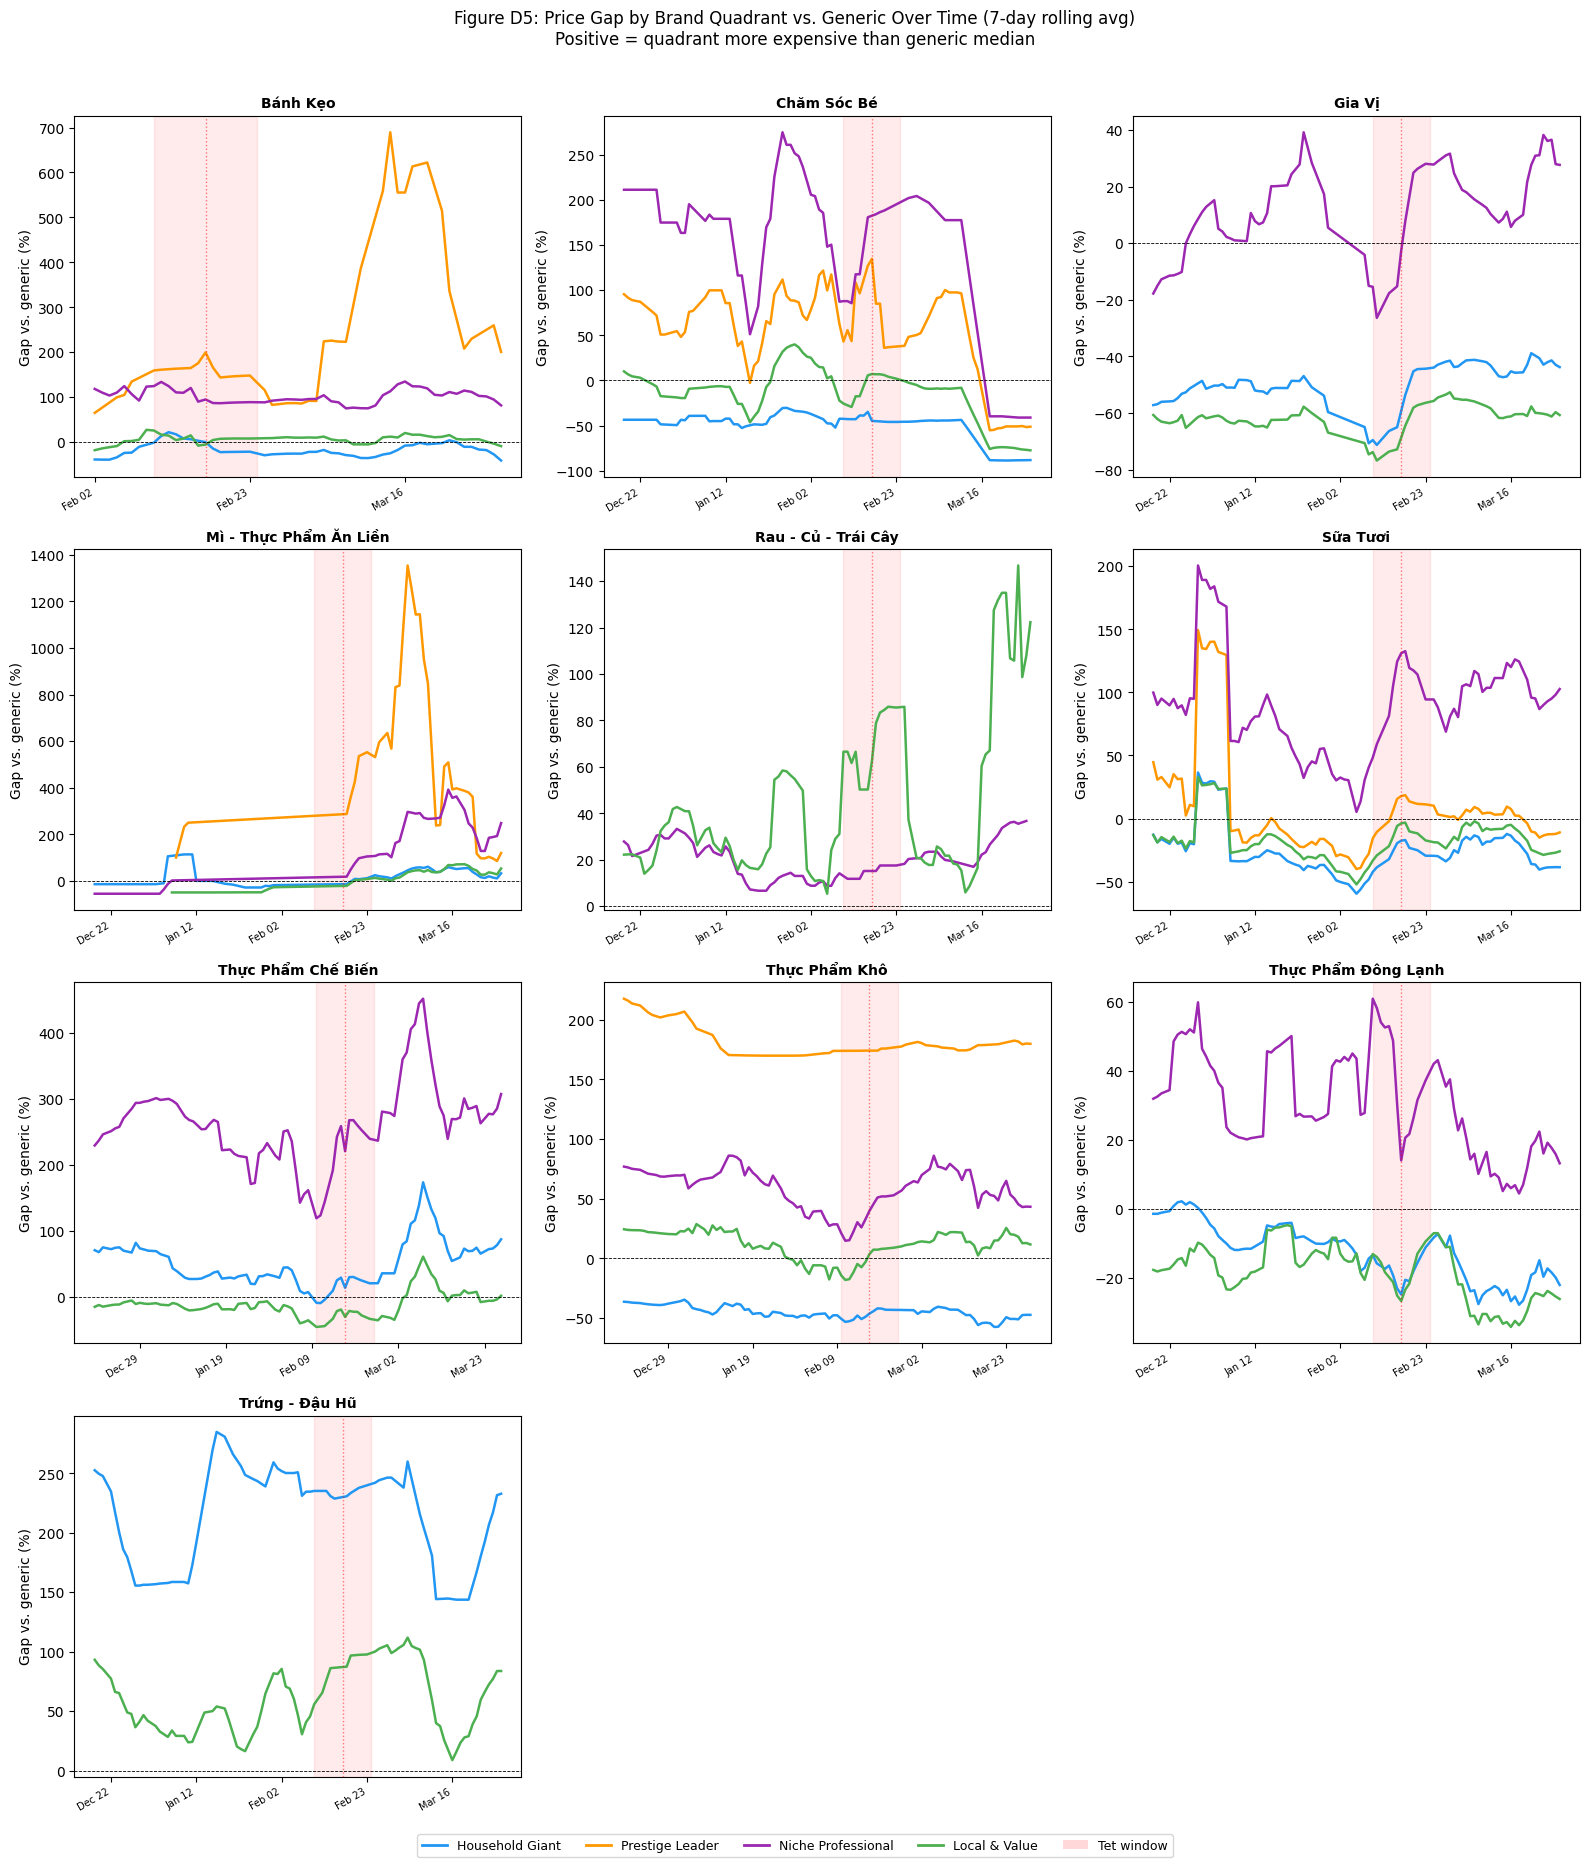

Figure D5 saved.


In [12]:
# Select categories with enough data across quadrants
quad_cats = quad_gap_final.groupby('parent_category')['brand_quadrant'].nunique()
quad_cats = quad_cats[quad_cats >= 2].index.tolist()

n_cats = len(quad_cats)
ncols = 3
nrows = int(np.ceil(n_cats / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(sorted(quad_cats)):
    ax = axes[i]
    df_cat = quad_gap_final[quad_gap_final['parent_category'] == cat]
    
    for quad in QUADRANT_ORDER:
        df_q = df_cat[df_cat['brand_quadrant'] == quad].sort_values('date').set_index('date')
        if df_q.empty:
            continue
        smoothed = df_q['gap_pct'].rolling(7, min_periods=3, center=True).mean()
        label = QUADRANT_LABELS.get(quad, quad)
        ax.plot(smoothed.index, smoothed.values, linewidth=1.8,
                color=QUADRANT_COLORS[quad], label=label)
    
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.axvspan(TET_WINDOW_START, TET_WINDOW_END, color='red', alpha=0.08)
    ax.axvline(TET_DATE, color='red', linewidth=1.0, linestyle=':', alpha=0.5)
    
    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Gap vs. generic (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Shared legend
handles = [
    plt.Line2D([0], [0], color=QUADRANT_COLORS[q], linewidth=2, label=QUADRANT_LABELS[q])
    for q in QUADRANT_ORDER
]
handles.append(Patch(facecolor='red', alpha=0.15, label='Tet window'))
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Figure D5: Price Gap by Brand Quadrant vs. Generic Over Time (7-day rolling avg)\n'
    'Positive = quadrant more expensive than generic median',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / 'output' / 'thesis_figD5_quadrant_gap_over_time.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Figure D5 saved.')

In [13]:
# Quadrant × Category summary with Tet comparison
quad_summary_rows = []
for (cat, quad), df_cq in quad_gap_final.groupby(['parent_category', 'brand_quadrant']):
    df_cq = df_cq.sort_values('date')
    in_tet = df_cq['date'].between(TET_WINDOW_START, TET_WINDOW_END)
    
    days = (df_cq['date'] - df_cq['date'].min()).dt.days.values
    if len(days) >= 5:
        slope, _, _, p_trend, _ = stats.linregress(days, df_cq['gap_pct'].values)
    else:
        slope, p_trend = np.nan, np.nan
    
    quad_summary_rows.append({
        'category': cat,
        'brand_quadrant': quad,
        'quadrant_label': QUADRANT_LABELS.get(quad, quad),
        'n_days': len(df_cq),
        'mean_gap_pct': df_cq['gap_pct'].mean(),
        'std_gap_pct': df_cq['gap_pct'].std(),
        'tet_mean_gap': df_cq.loc[in_tet, 'gap_pct'].mean() if in_tet.any() else np.nan,
        'non_tet_mean_gap': df_cq.loc[~in_tet, 'gap_pct'].mean() if (~in_tet).any() else np.nan,
        'trend_slope': slope,
        'trend_p': p_trend,
    })

quad_cat_summary = pd.DataFrame(quad_summary_rows).round(3)
quad_cat_summary['tet_delta'] = quad_cat_summary['tet_mean_gap'] - quad_cat_summary['non_tet_mean_gap']

out_path = PROJECT_ROOT / 'output' / 'brand_gap_summary_by_quadrant.csv'
quad_cat_summary.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Saved {len(quad_cat_summary)} rows → {out_path}")

# Pivot: mean gap by quadrant across categories
print("\nMean gap (%) vs. generic by quadrant × category:")
pivot = quad_cat_summary.pivot_table(
    index='category', columns='quadrant_label', values='mean_gap_pct'
).round(1)
pivot

Saved 33 rows → /Users/my/Online Food Price/notebooks/../output/brand_gap_summary_by_quadrant.csv

Mean gap (%) vs. generic by quadrant × category:


quadrant_label,Household Giant,Local & Value,Niche Professional,Prestige Leader
category,,,,
Bánh Kẹo,-17.0,6.3,102.8,240.3
Chăm Sóc Bé,-50.3,-14.8,144.6,57.2
Gia Vị,-49.7,-61.8,11.0,NaN
Mì - Thực Phẩm Ăn Liền,18.5,0.4,151.4,502.7
Rau - Củ - Trái Cây,NaN,44.7,19.9,NaN
Sữa Tươi,-25.8,-17.6,89.2,6.8
Thực Phẩm Chế Biến,52.3,-10.7,264.0,NaN
Thực Phẩm Khô,-45.1,11.4,58.0,183.4
Thực Phẩm Đông Lạnh,-12.6,-18.6,30.8,NaN
